In [1]:
#Importing the necessary libraries
import matplotlib.pyplot as plt
from nltk import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
import pandas as pd
import sys
import unicodedata

#Importing the articles
articles = pd.read_csv('articles1.csv')
articles.head()

,Unnamed: 0,id,title,publication,author,date,year,month,url,content
0,0,17283,House Republicans Fret About Winning Their Hea...,New York Times,Carl Hulse,2016-12-31,2016.0,12.0,NaN,WASHINGTON — Congressional Republicans have...
1,1,17284,Rift Between Officers and Residents as Killing...,New York Times,Benjamin Mueller and Al Baker,2017-06-19,2017.0,6.0,NaN,"After the bullet shells get counted, the blood..."
2,2,17285,"Tyrus Wong, ‘Bambi’ Artist Thwarted by Racial ...",New York Times,Margalit Fox,2017-01-06,2017.0,1.0,NaN,"When Walt Disney’s “Bambi” opened in 1942, cri..."
3,3,17286,"Among Deaths in 2016, a Heavy Toll in Pop Musi...",New York Times,William McDonald,2017-04-10,2017.0,4.0,NaN,"Death may be the great equalizer, but it isn’t..."
4,4,17287,Kim Jong-un Says North Korea Is Preparing to T...,New York Times,Choe Sang-Hun,2017-01-02,2017.0,1.0,NaN,"SEOUL, South Korea — North Korea’s leader, ..."


In [ ]:
'''
I want to test the hypothesis 'Articles about Climate Change are more likely to be published by "Liberal" sources.'
To do this, I will separate the articles by their source and count the number of articles of each publisher that 
mention the phrases 'climate change' or 'sea level' at least twice. To compare across publishers, I will divide 
that number by the total number of articles of each publisher to determine the percent of climate change articles.
'''

In [2]:
#Before separating the articles by their publication, the text must be cleaned

#Converting all content text to lowercase
articles['content'] = articles['content'].str.lower()

In [3]:
#Removing punctuation 
punctuation = dict.fromkeys(i for i in range(sys.maxunicode) if unicodedata.category(chr(i)).startswith('P'))
articles['content'] = [string.translate(punctuation) for string in articles['content']]

In [4]:
#Now that the article content has been cleaned, I will separate the articles by their publisher
NYT = articles[articles.publication == 'New York Times']
BB = articles[articles.publication == 'Breitbart']
CNN = articles[articles.publication == 'CNN']
BI = articles[articles.publication == 'Business Insider']
A = articles[articles.publication == 'Atlantic']

In [5]:
#Initializing counts for how many climate change articles each publisher has written
nytCount = 0
bbCount = 0
cnnCount = 0
biCount = 0
aCount = 0

In [6]:
#Finding the number of New York Times articles that mention climate change or sea levels more than 10 times 
for i in NYT.index[0:-1]:
    if NYT['content'][i].find('climate change') > 5 or NYT['content'][i].find('sea level') > 5:
        nytCount += 1

print(nytCount / len(NYT) * 100)

3.9215686274509802


In [7]:
for i in BB.index[0:-1]:
    if BB['content'][i].find('climate change') > 5 or BB['content'][i].find('sea level') > 5:
        bbCount += 1
        
print(bbCount / len(BB) * 100)

1.602119338968084


In [8]:
for i in CNN.index[0:-1]:
    if CNN['content'][i].find('climate change') > 5 or CNN['content'][i].find('sea level') > 5:
        cnnCount += 1
        
print(cnnCount / len(CNN) * 100)

2.2197075208913652


In [9]:
for i in BI.index[0:-1]:
    if BI['content'][i].find('climate change') > 5 or BI['content'][i].find('sea level') > 5:
        biCount += 1
        
print(biCount / len(BI) * 100)

1.2579547136303093


In [10]:
for i in A.index[0:-1]:
    if A['content'][i].find('climate change') > 5 or A['content'][i].find('sea level') > 5:
        aCount += 1
        
print(aCount / len(A) * 100)

11.11111111111111


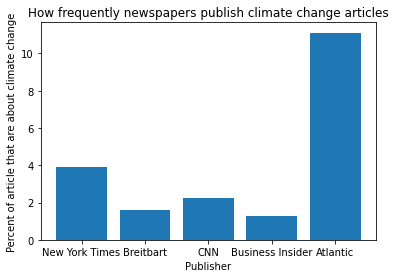

In [22]:
names = [NYT.publication.unique()[0], BB.publication.unique()[0], CNN.publication.unique()[0], BI.publication.unique()[0], A.publication.unique()[0]]
percents = [nytCount / len(NYT) * 100, bbCount / len(BB) * 100, cnnCount / len(CNN) * 100, biCount / len(BI) * 100, aCount / len(A) * 100]

plt.bar(names, percents)
plt.xlabel('Publisher')
plt.ylabel('Percent of article that are about climate change')
plt.title('How frequently newspapers publish climate change articles')
plt.show()